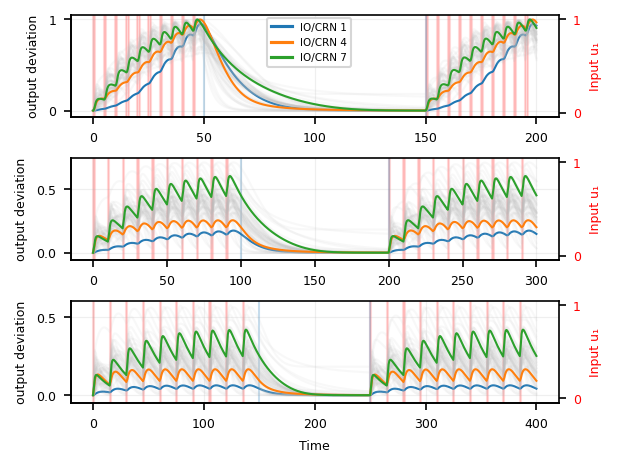

In [1]:
from RL4CRN.utils.input_interface import load_session_and_trainer
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

task_name = "Habituation_h3_Task_sensitization"
checkpoint_path = f"{task_name}.pkl"

trainer = load_session_and_trainer(checkpoint_path, device="cuda")

# ---- settings ----
fin = 50
selected = [0, 3, 6]
ylabel = "output deviation"

# Standard matplotlib color cycle
std_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sel_color_map = {idx: std_colors[i % len(std_colors)] for i, idx in enumerate(selected)}

# Smaller figure + 6 pt legend font
plot_cfg_main = {
    "figsize": (4., 3.),
    "constrained_layout": True,
    "tight_layout": False,
    "legend": False,  # build legend manually
    "rc": {
        "legend.fontsize": 6,
    },
}

fig, axes = None, None

# 1) Main selected trajectory (creates figure, applies styling, keeps ylabel)
first_main = selected[0]
sol = trainer.s.mult_env.hall_of_fame[first_main].state
fig, axes = sol.plot_transient_response_piecewise(
    fig=fig,
    axes=axes,
    gap=True,
    is_main=True,
    trj_color=sel_color_map[first_main],
    normalize=True,
    y_label=ylabel,              # <- direct argument
    plot_cfg=plot_cfg_main,
)

# 2) Background trajectories in gray
for index in range(fin):
    if index in selected:
        continue
    sol = trainer.s.mult_env.hall_of_fame[index].state
    fig, axes = sol.plot_transient_response_piecewise(
        fig=fig,
        axes=axes,
        gap=True,
        is_main=False,
        alpha=0.10,
        trj_color="0.75",
        normalize=True,
        y_label=ylabel,          # <- direct argument
        plot_cfg={},
    )

# 3) Overlay selected trajectories on top with standard palette colors
for index in selected[1:]:
    sol = trainer.s.mult_env.hall_of_fame[index].state
    fig, axes = sol.plot_transient_response_piecewise(
        fig=fig,
        axes=axes,
        gap=True,
        is_main=False,
        alpha=1.0,
        trj_color=sel_color_map[index],
        normalize=True,
        y_label=ylabel,          # <- direct argument
        plot_cfg={},
    )

# 4) Manual legend (robust, independent of plot labels)
legend_handles = [
    Line2D([0], [0], color=sel_color_map[idx], lw=1.5, label=f"IO/CRN {idx+1}")
    for idx in selected
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=1,#len(selected),
    frameon=True,
    fontsize=5,
)

fig.savefig("sensitization.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [2]:
for i in selected:
    print("IO/CRN", i+1)
    print(trainer.s.mult_env.hall_of_fame[i].state)

IO/CRN 1
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(0.1)]
X_2 ----> ∅;  [MAK(0.1)]
X_2 ----> X_1 + X_2;  [MAK(0.44269517064094543)]
X_3 ----> ∅;  [MAK(0.1)]
X_3 ----> X_2 + X_2;  [MAK(0.3158538043498993)]
X_1 + X_3 ----> X_3 + X_3;  [MAK(0.14039254188537598)]
X_2 + X_2 ----> X_1;  [MAK(2.0098743438720703)]
X_2 + X_2 ----> X_3;  [MAK(0.8677883148193359)]
IO/CRN 4
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(0.1)]
X_2 ----> ∅;  [MAK(0.1)]
X_3 ----> ∅;  [MAK(0.1)]
X_1 + X_2 ----> ∅;  [MAK(0.22019033133983612)]
X_1 + X_2 ----> X_1 + X_3;  [MAK(0.17026260495185852)]
X_1 + X_3 ----> X_3 + X_3;  [MAK(0.11212466657161713)]
X_2 + X_3 ----> X_1;  [MAK(0.09815887361764908)]
X_2 + X_3 ----> X_1 + X_1;  [MAK(0.5266243815422058)]
IO/CRN 7
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output S

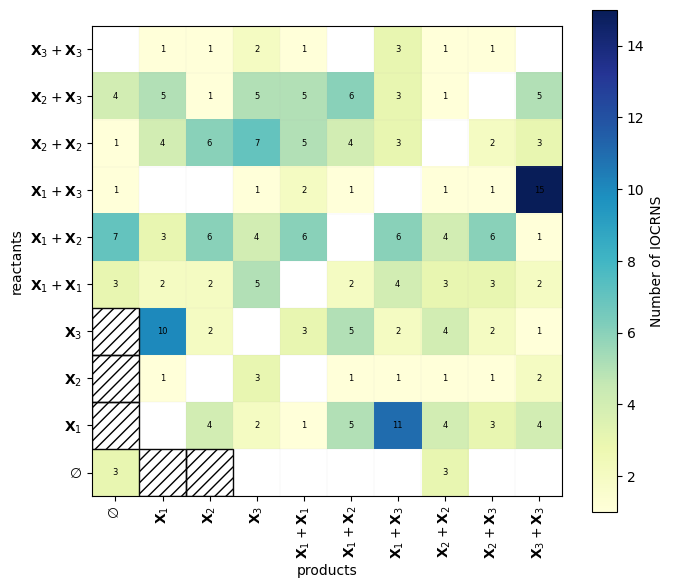

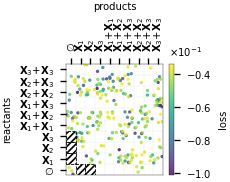

In [3]:
from RL4CRN.utils.visualizations import plot_reactant_product_heatmap, plot_reactant_product_scatter, topology_graph

all_iocrns_sorted_filtered = [c.state for c in trainer.s.mult_env.hall_of_fame]
species_labels = ["X_1", "X_2", "X_3"]

plot_reactant_product_heatmap(
    all_iocrns_sorted_filtered,
    species_labels,
    max_order= 2,
    num_reactions_template=5,
    title="",
    cmap_name="YlGnBu",
    max_ticks=20,
    figsize=(7, 6),
)

# Plot the reactant-product scatter for the top unfiltered IOCRNs
rewards_sorted = [iocrn.state.last_task_info['reward'] for iocrn in trainer.s.mult_env.hall_of_fame]

# Reactant-Product Scatter Plot
plot_dic = {
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 6,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.2,
        "lines.linewidth": 1.2,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

fig = plot_reactant_product_scatter(
    all_iocrns_sorted_filtered,
    perf=rewards_sorted,
    species_labels=species_labels,
    max_order= 2,
    num_reactions_template=5,
    title="",
    cmap_name="viridis",
    max_ticks=30,
    figsize=(2*1., 1.65*1.),
    jitter_scale=0.45,
    use_plotly=False,
    plot_dic=plot_dic,
    marker_size=4,
)

import os
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_nicolo/Habituation_3s_5r_MAK_REINFORCE/"
fig.savefig(os.path.join(target_directory, 'plots', f"{task_name}_reactant_product_scatter.pdf"))

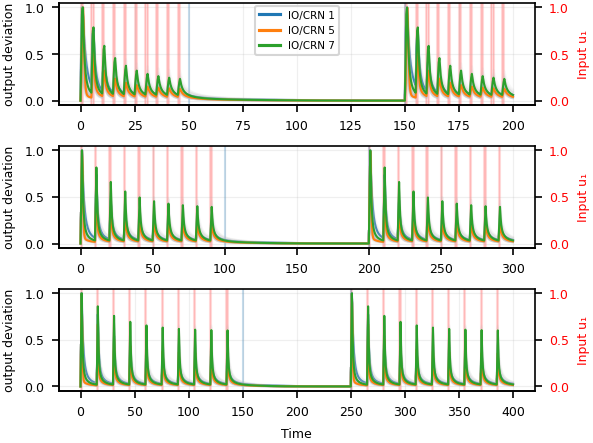

In [4]:
from RL4CRN.utils.input_interface import load_session_and_trainer
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

task_name = "Habituation_h3_Task"
checkpoint_path = f"{task_name}.pkl"

trainer = load_session_and_trainer(checkpoint_path, device="cuda")

# ---- settings ----
fin = 50
selected = [0, 4, 6]
ylabel = "output deviation"

# Standard matplotlib color cycle
std_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sel_color_map = {idx: std_colors[i % len(std_colors)] for i, idx in enumerate(selected)}

# Smaller figure + 6 pt legend font
plot_cfg_main = {
    "figsize": (4., 3.),
    "constrained_layout": True,
    "tight_layout": False,
    "legend": False,  # build legend manually
    "rc": {
        "legend.fontsize": 6,
    },
}

fig, axes = None, None

# 1) Main selected trajectory (creates figure, applies styling, keeps ylabel)
first_main = selected[0]
sol = trainer.s.mult_env.hall_of_fame[first_main].state
fig, axes = sol.plot_transient_response_piecewise(
    fig=fig,
    axes=axes,
    gap=True,
    is_main=True,
    trj_color=sel_color_map[first_main],
    normalize=True,
    y_label=ylabel,              # <- direct argument
    plot_cfg=plot_cfg_main,
)

# 2) Background trajectories in gray
for index in range(fin):
    if index in selected:
        continue
    sol = trainer.s.mult_env.hall_of_fame[index].state
    fig, axes = sol.plot_transient_response_piecewise(
        fig=fig,
        axes=axes,
        gap=True,
        is_main=False,
        alpha=0.10,
        trj_color="0.75",
        normalize=True,
        y_label=ylabel,          # <- direct argument
        plot_cfg={},
    )

# 3) Overlay selected trajectories on top with standard palette colors
for index in selected[1:]:
    sol = trainer.s.mult_env.hall_of_fame[index].state
    fig, axes = sol.plot_transient_response_piecewise(
        fig=fig,
        axes=axes,
        gap=True,
        is_main=False,
        alpha=1.0,
        trj_color=sel_color_map[index],
        normalize=True,
        y_label=ylabel,          # <- direct argument
        plot_cfg={},
    )

# 4) Manual legend (robust, independent of plot labels)
legend_handles = [
    Line2D([0], [0], color=sel_color_map[idx], lw=1.5, label=f"IO/CRN {idx+1}")
    for idx in selected
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=1,#len(selected),
    frameon=True,
    fontsize=5,
)

fig.savefig("habituation.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
for i in selected:
    print("IO/CRN", i+1)
    print(trainer.s.mult_env.hall_of_fame[i].state)

IO/CRN 1
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> ∅;  [MAK(1.2253799438476562)]
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(0.1)]
X_1 ----> X_1 + X_3;  [MAK(51.82826232910156)]
X_2 ----> ∅;  [MAK(0.1)]
X_3 ----> ∅;  [MAK(0.1)]
X_1 + X_3 ----> X_3;  [MAK(0.7332110404968262)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(0.7588115334510803)]
X_3 + X_3 ----> ∅;  [MAK(5.881089210510254)]
IO/CRN 5
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> ∅;  [MAK(2.4425129890441895)]
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(0.1)]
X_1 ----> X_1 + X_3;  [MAK(12.26185131072998)]
X_2 ----> ∅;  [MAK(0.1)]
X_3 ----> ∅;  [MAK(0.1)]
X_1 + X_3 ----> X_3;  [MAK(0.5445803999900818)]
X_1 + X_3 ----> X_2 + X_3;  [MAK(0.2841651439666748)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(0.4598430097103119)]
IO/CRN 7
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> ∅;  [MAK(1

range(0, 50) [-0.11834752765044271, -0.09668121608323714, -0.0961555267602149, -0.09333500162695174, -0.09128744279284633, -0.08979771729063195, -0.08906246096698382, -0.08851600062736258, -0.08658508019942106, -0.08573729237509897, -0.08550683285693565, -0.08500706802435004, -0.08364581813537635, -0.08321844981558328, -0.08188062889398857, -0.08095414318949619, -0.07949306781370082, -0.07887667621347709, -0.07825129555568024, -0.07721865834383816, -0.07652726667388328, -0.07571549314116119, -0.07420328277270466, -0.07374741236549802, -0.07205869782851118, -0.06945907822142383, -0.06930049364990143, -0.06808065335373027, -0.06622206359418115, -0.065277425327346, -0.06378874689899659, -0.061450460326555684, -0.060306661379030936, -0.06001367486665141, -0.05973878827272707, -0.058926840599609426, -0.058115367408239575, -0.05782957856698016, -0.057745013036586544, -0.05744378907205335, -0.05722144722560146, -0.054646936592142835, -0.05437521278212585, -0.054223243606730885, -0.05392876027

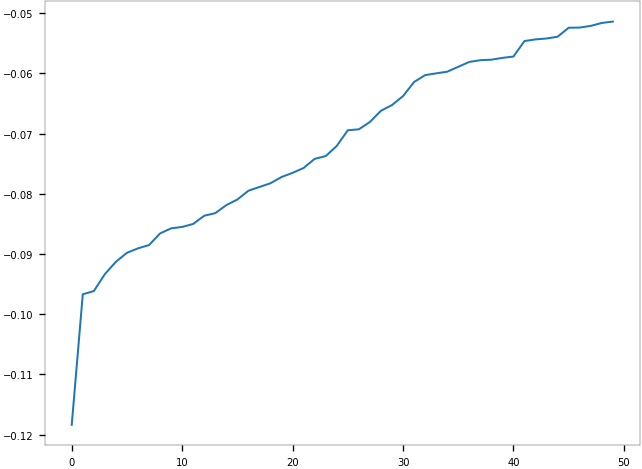

In [6]:
losses = []
for i in range(50):
    sol = trainer.s.mult_env.hall_of_fame[i].state
    losses.append(sol.last_task_info["reward"])

# flush all plots
plt.clf()
plt.plot(losses)
print(range(0,len(losses)), losses)
plt.show()

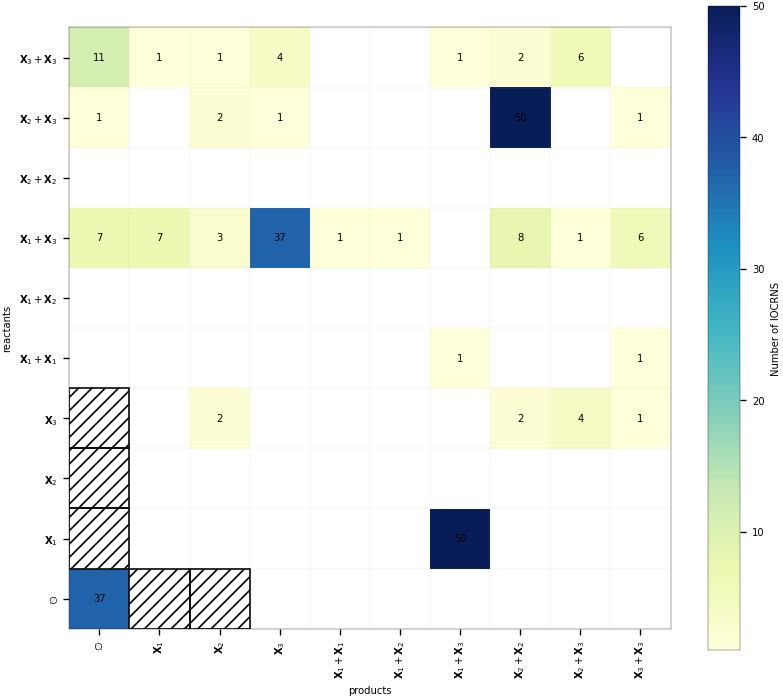

In [7]:
from RL4CRN.utils.visualizations import plot_reactant_product_heatmap, plot_reactant_product_scatter, topology_graph

all_iocrns_sorted_filtered = [c.state for c in trainer.s.mult_env.hall_of_fame]
species_labels = ["X_1", "X_2", "X_3"]

plot_reactant_product_heatmap(
    all_iocrns_sorted_filtered,
    species_labels,
    max_order= 2,
    num_reactions_template=5,
    title="",
    cmap_name="YlGnBu",
    max_ticks=20,
    figsize=(7, 6),
)

In [8]:
# Plot the reactant-product scatter for the top unfiltered IOCRNs
rewards_sorted = [iocrn.state.last_task_info['reward'] for iocrn in trainer.s.mult_env.hall_of_fame]

# Reactant-Product Scatter Plot
plot_dic = {
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 6,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.2,
        "lines.linewidth": 1.2,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

fig = plot_reactant_product_scatter(
    all_iocrns_sorted_filtered,
    perf=rewards_sorted,
    species_labels=species_labels,
    max_order= 2,
    num_reactions_template=5,
    title="",
    cmap_name="viridis",
    max_ticks=30,
    figsize=(2*5., 1.65*5.),
    jitter_scale=0.45,
    use_plotly=True,
    plot_dic=plot_dic,
    marker_size=4,
)

import os
target_directory = "/local0/rossin/git/CRN-GenerativeAI/apps_nicolo/Habituation_3s_5r_MAK_REINFORCE/"
# fig.savefig(os.path.join(target_directory, 'plots', f"{task_name}_reactant_product_scatter.pdf"))

In [9]:
print(trainer.s.mult_env.hall_of_fame[4].state)

Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_3'] 
∅ ----> ∅;  [MAK(2.4425129890441895)]
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(0.1)]
X_1 ----> ∅;  [MAK(0.1)]
X_1 ----> X_1 + X_3;  [MAK(12.26185131072998)]
X_2 ----> ∅;  [MAK(0.1)]
X_3 ----> ∅;  [MAK(0.1)]
X_1 + X_3 ----> X_3;  [MAK(0.5445803999900818)]
X_1 + X_3 ----> X_2 + X_3;  [MAK(0.2841651439666748)]
X_2 + X_3 ----> X_2 + X_2;  [MAK(0.4598430097103119)]
